# 02 — BRL/USD Producer-Selling Signal (Discovery)

**Goal:** Test whether the *trend* in the Brazilian real (USD/BRL) carries **forward-predictive** information about ICE Arabica (KC) coffee prices — the first, deliberately simple pass at the producer-selling hypothesis.

**Economic hypothesis (producer-selling channel).** Brazil is the dominant Arabica producer. Producers sell in USD but spend in reais. When the real *weakens*, each USD of coffee sold converts into more reais, so local-currency revenue improves even if the USD price is unchanged. That raises the incentive to **sell / release inventory**, adding supply to the world market and pushing the **USD coffee price down** over the following weeks–months.

**Sign convention (read this once, it governs everything below).**
`BRL=X` on Yahoo is **USD/BRL = reais per 1 USD**.
- Real *weakens* ⟺ USD/BRL **rises** ⟺ positive momentum (ROC > 0).
- Thesis ⟹ a weakening real today predicts **lower** coffee prices ahead.
- Therefore the thesis predicts a **negative** correlation:  `r( BRL_momentum_t , coffee_return_{t→t+N} ) < 0`.

For a buyer the eventual reading is intuitive: *real weakening → cheaper coffee coming → wait*; *real strengthening → coffee firming → buy now*. We are **not** building that buy signal yet (see Scope).

**Gates for this discovery notebook (pass/fail, evidence not story):**
1. **Effect exists** — forward-predictive `r` is negative and statistically distinguishable from zero (p < 0.10) at *some* horizon N.
2. **Signal leads, not lags** — at the chosen horizon the *forward* r is at least as strong as the **horizon-matched trailing** r. Comparing forward-N against trailing-N (same return length, just shifted in time) removes the artifact that multi-month returns are mechanically smoother than short ones. A signal that only correlates with *past* coffate moves is coincident/lagging, not predictive, and fails the gate.
3. **Not one episode** — the rolling correlation keeps the predicted sign across subperiods rather than being entirely produced by a single regime (e.g. the 2014–2016 real collapse or 2020 COVID).

**Scope — what this notebook does and does NOT do.**
This is the *raw* test on purpose. It does **not** yet control for confounders, and a raw result here is **suggestive, not conclusive**. The following are scaffolded as explicit hooks in §7 for later notebooks:
- **Broad-dollar control (DXY).** USD/BRL and USD-priced commodities both move with the dollar; the coffee-specific signal must survive orthogonalising against DXY.
- **Reverse causality.** Coffee export revenue supports the real, so causality can run coffee→BRL. A Granger-style lead/lag test is needed.
- **Import-weighted FX basket.** Generalise beyond Brazil to a US-green-import-weighted basket (BRL, COP, …).
- **Gated buy-timing signal** with cost-saving validation, in the style of notebook 01.

**Data sources (no API key, same pattern as NB1):**
- Coffee: Yahoo Finance `KC=F` (ICE Coffee C front-month futures, USc/lb).
- FX: Yahoo Finance `BRL=X` (USD/BRL spot).

## 0. Setup

Import dependencies and fix the analysis window. Every downstream cell depends on `BACKTEST_START` / `BACKTEST_END` — change them here to re-scope the study. The window starts in 2005 so the 2008 GFC, the 2014–2016 real collapse, and 2020 COVID are all *in-sample* stress episodes for the stability test in §5b (Yahoo's `BRL=X` and `KC=F` both extend back this far).

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats

# Analysis window. 2005 start => 2008 GFC, 2014-16 BRL collapse, 2020 COVID
# are all inside the sample for the stability test in §5b.
BACKTEST_START = date(2005, 1, 1)
BACKTEST_END   = date.today()

# Horizons (in months) at which we test forward-predictive power.
# The producer-selling / inventory-release channel should act FAST (weeks to a
# few months), so we scan short horizons too — not just NB1's 12/24m cycle.
HORIZONS = [1, 2, 3, 6, 12, 24]

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(f"Window : {BACKTEST_START} -> {BACKTEST_END}")
print(f"Horizons tested (months): {HORIZONS}")

Window : 2005-01-01 -> 2026-06-17
Horizons tested (months): [1, 2, 3, 6, 12, 24]


## 1. Fetch Data

Download the two daily series from Yahoo Finance and align them on a common calendar.

- **`KC=F`** — ICE Coffee C front-month futures (USc/lb). Same instrument as NB1; `Close` is used as the settlement proxy.
- **`BRL=X`** — USD/BRL spot (reais per USD).

**Input:** two tickers + the date window.
**Output:** a daily `DataFrame` with columns `settle` (coffee) and `usdbrl` (FX), inner-joined so only dates present in *both* series survive. We inner-join because a feature built from a misaligned FX value would silently corrupt every correlation downstream.

In [2]:
def fetch_close(ticker: str, name: str) -> pd.Series:
    '''Download one ticker's daily Close from Yahoo and return a clean Series.

    Inputs : ticker (Yahoo symbol), name (column name to assign).
    Output : pd.Series indexed by datetime 'date', NaNs dropped.
    auto_adjust=True matches NB1; for futures/FX it leaves the level intact.
    '''
    raw = yf.download(
        ticker,
        start=BACKTEST_START.isoformat(),
        end=BACKTEST_END.isoformat(),
        auto_adjust=True,
        progress=False,
    )
    s = raw["Close"].squeeze().rename(name).dropna()   # squeeze: 1-col frame -> Series
    s.index = pd.to_datetime(s.index)
    s.index.name = "date"
    return s

coffee = fetch_close("KC=F", "settle")     # USc/lb
usdbrl = fetch_close("BRL=X", "usdbrl")    # reais per USD

# Inner-join on the shared trading calendar (coffee and FX holidays differ).
df = pd.concat([coffee, usdbrl], axis=1, join="inner").dropna()

print("Coffee (KC=F) :", coffee.index.min().date(), "->",
      coffee.index.max().date(), f"({len(coffee)} obs)")
print("FX (BRL=X)    :", usdbrl.index.min().date(), "->",
      usdbrl.index.max().date(), f"({len(usdbrl)} obs)")
print("Aligned daily :", df.index.min().date(), "->", df.index.max().date(), f"({len(df)} rows)")

Coffee (KC=F) : 2005-01-03 -> 2026-06-16 (5392 obs)
FX (BRL=X)    : 2006-03-24 -> 2026-06-17 (5237 obs)
Aligned daily : 2006-03-24 -> 2026-06-16 (5050 rows)


In [3]:
df.describe()

,settle,usdbrl
count,"5,050.0000","5,050.0000"
mean,166.9971,3.4186
std,69.2330,1.4501
min,86.6500,1.5337
25%,118.6625,2.0312
50%,139.5000,3.2207
75%,193.6500,5.0200
max,438.9000,6.3000


## 2. Data Quality

Two checks before any feature is built:
1. **Visual inspection** of both levels over the full window — confirm neither series has obvious bad ticks or flat-lined gaps that would distort a rolling momentum window.
2. **Alignment / NaN audit** over the core window — any NaN inside a `pct_change` or `rolling` window propagates forward and *inflates apparent signal strength*, the same failure mode flagged in NB1 §2.

The two series are plotted on separate axes because they live on different scales (USc/lb vs reais/USD); the point is to eyeball *co-movement and timing*, not levels.

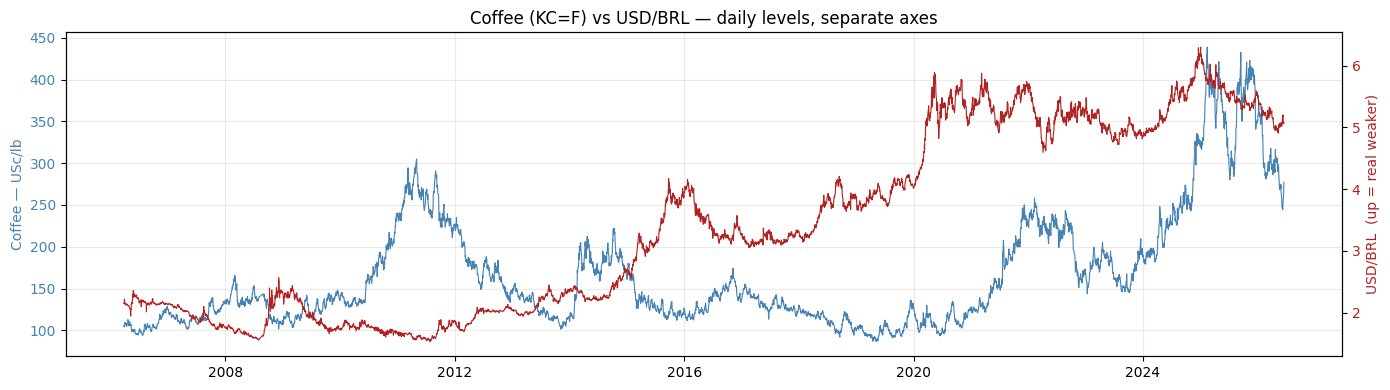

NaN counts (aligned daily frame):
settle    0
usdbrl    0
dtype: int64

Total aligned trading days : 5050
Date span                  : 2006-03-24 -> 2026-06-16
Largest calendar gap between aligned rows : 26 days


In [4]:
fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(df.index, df["settle"], lw=0.8, color="steelblue", label="Coffee KC=F (USc/lb)")
ax1.set_ylabel("Coffee — USc/lb", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()  # second y-axis sharing the same x (time)
ax2.plot(df.index, df["usdbrl"], lw=0.8, color="firebrick", label="USD/BRL (reais per USD)")
ax2.set_ylabel("USD/BRL  (up = real weaker)", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")

ax1.set_title("Coffee (KC=F) vs USD/BRL — daily levels, separate axes")
ax1.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# NaN / coverage audit on the aligned frame.
print("NaN counts (aligned daily frame):")
print(df.isna().sum())
print(f"\nTotal aligned trading days : {len(df)}")
print(f"Date span                  : {df.index.min().date()} -> {df.index.max().date()}")
# Largest gap between consecutive aligned dates (flags any hidden hole).
gap = df.index.to_series().diff().max()
print(f"Largest calendar gap between aligned rows : {gap.days} days")

## 3. Feature Engineering

You asked for forex **trends**, so the signal is FX *momentum*, not the raw level — "weak *and weakening*" real, not merely "weak". We build two trend representations and the forward coffee returns the signal must predict.

**FX trend features (computed on daily data, then sampled month-end):**

```
brl_roc_3m  = USD/BRL_t / USD/BRL_{t-63}  - 1      # ~3-month rate of change
brl_ma_dev  = USD/BRL_t / mean(USD/BRL, 126d) - 1  # deviation from ~6m moving avg
```
- `63` trading days ≈ 3 calendar months; `126` ≈ 6 months.
- Both are **positive when the real is weakening** (USD/BRL rising), so under the thesis both should correlate **negatively** with forward coffee returns.
- `brl_roc_3m` captures *recent* directional thrust; `brl_ma_dev` captures *how stretched* the real is versus its own trend. We test which form predicts better in §6.

**Target — forward coffee return at horizon N months:**

```
fwd_{N}m_t = Coffee_{t+N} / Coffee_t - 1
```
This is measured **entirely after t**, so pairing it with a signal known **at t** is a genuine out-of-sample-in-time predictive test (no look-ahead). The signal uses only past prices; the target uses only future prices; the two windows never overlap.

We also build the **trailing** N-month return `trl_{N}m_t = Coffee_t / Coffee_{t-N} - 1` (strictly past). It is the *horizon-matched* benchmark for §4/§5: comparing forward-N against trailing-N — same return length, opposite time direction — is the clean test of whether the FX signal **leads** coffee or merely **lags/coincides** with it.

We then resample daily → **month-end** (`"ME"`), matching NB1's monthly cadence, because a buyer makes purchasing decisions monthly, not tick-by-tick, and monthly sampling removes daily FX noise that has nothing to do with the supply channel.

In [5]:
# ── FX trend features on the DAILY series (more resolution for the rolling ops),
#    then we resample to month-end so the analysis cadence matches a buyer's. ──
TRADING_DAYS_3M = 63    # ~3 calendar months of trading days
TRADING_DAYS_6M = 126   # ~6 calendar months

df["brl_roc_3m"] = df["usdbrl"].pct_change(TRADING_DAYS_3M)
df["brl_ma_dev"] = df["usdbrl"] / df["usdbrl"].rolling(TRADING_DAYS_6M).mean() - 1.0

# Month-end snapshot. .last() takes the final observation in each month, which is
# the value a buyer would actually see at month-end.
monthly = df.resample("ME").last()

# Forward coffee returns at each horizon (target the signal must predict).
# shift(-N) pulls a FUTURE price back to the current row; the return therefore
# looks strictly forward from t to t+N. Trailing rows become NaN (no future yet).
for N in HORIZONS:
    # FORWARD return t -> t+N : strictly future, the predictive target.
    monthly[f"fwd_{N}m"] = monthly["settle"].shift(-N) / monthly["settle"] - 1.0
    # TRAILING return t-N -> t : strictly past, the horizon-matched benchmark
    # used in §4 so the lead/lag comparison in §5 is like-for-like.
    monthly[f"trl_{N}m"] = monthly["settle"].pct_change(N)

print(f"Monthly rows: {len(monthly)}   "
      f"({monthly.index.min().date()} -> {monthly.index.max().date()})")
print("\nFeature columns now present:")
print([c for c in monthly.columns if c.startswith('brl_') or c.startswith('fwd_')])
monthly[["settle", "usdbrl", "brl_roc_3m", "brl_ma_dev"]].tail()

Monthly rows: 244   (2006-03-31 -> 2026-06-30)

Feature columns now present:
['brl_roc_3m', 'brl_ma_dev', 'fwd_1m', 'fwd_2m', 'fwd_3m', 'fwd_6m', 'fwd_12m', 'fwd_24m']


,settle,usdbrl,brl_roc_3m,brl_ma_dev
date,,,,
2026-02-28,284.6000,5.1366,-0.0464,-0.0406
2026-03-31,298.3500,5.2640,-0.0502,-0.0122
2026-04-30,300.9000,5.0175,-0.0346,-0.0483
2026-05-31,265.6000,5.0517,-0.0165,-0.0316
2026-06-30,277.2500,5.0751,-0.0302,-0.0222


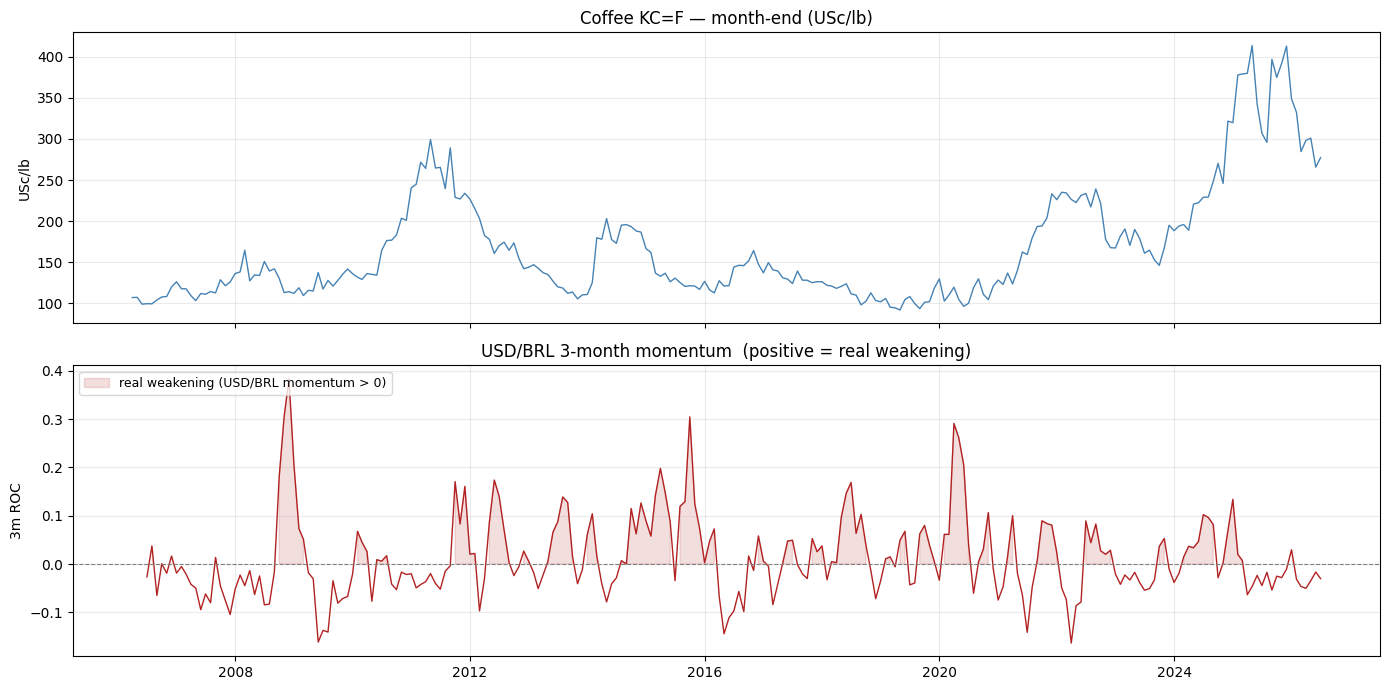

In [6]:
# Visual: coffee vs the FX-momentum signal, monthly. Shaded band = real weakening
# (brl_roc_3m > 0), the regime the thesis says should precede SOFTER coffee.
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(monthly.index, monthly["settle"], lw=1.0, color="steelblue")
axes[0].set_title("Coffee KC=F — month-end (USc/lb)")
axes[0].set_ylabel("USc/lb")
axes[0].grid(alpha=0.25)

axes[1].plot(monthly.index, monthly["brl_roc_3m"], lw=1.0, color="firebrick")
axes[1].axhline(0, ls="--", color="gray", lw=0.8)
axes[1].fill_between(monthly.index, 0, monthly["brl_roc_3m"],
                     where=monthly["brl_roc_3m"] > 0, color="firebrick", alpha=0.15,
                     label="real weakening (USD/BRL momentum > 0)")
axes[1].set_title("USD/BRL 3-month momentum  (positive = real weakening)")
axes[1].set_ylabel("3m ROC")
axes[1].legend(loc="upper left", fontsize=9)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 4. Trailing (lagging) Relationship — the benchmark for "does it lead?"

**Question:** how strongly does USD/BRL momentum at t correlate with coffee's **past** N-month return (the move that already happened, `trl_{N}m`)?

This is the benchmark, not the result. A strong *trailing* correlation means the FX signal **lags or coincides** with coffee — useless to a buyer, who needs lead time — and is exactly what reverse causality (coffee revenue → real) or a shared dollar factor would produce. NB1 made the same point: its headline r=0.64 was contemporaneous, while genuine forward power was far smaller. We compute trailing r at **every horizon** so §5's forward r can be compared to it **like-for-like at the same horizon** (Gate 2). 

If trailing r is large and negative but forward r is not, the signal merely *reflects* coffee moves that already occurred — evidence *against* a usable signal, however good the story sounds.

Trailing r( brl_roc_3m_t , PAST coffee return t-N -> t ):

           r_trailing  p_value    n
horizon_m                          
1             -0.1683   0.0088  241
2             -0.2262   0.0004  241
3             -0.3220   0.0000  241
6             -0.2555   0.0001  238
12            -0.1891   0.0038  232
24            -0.1855   0.0058  220


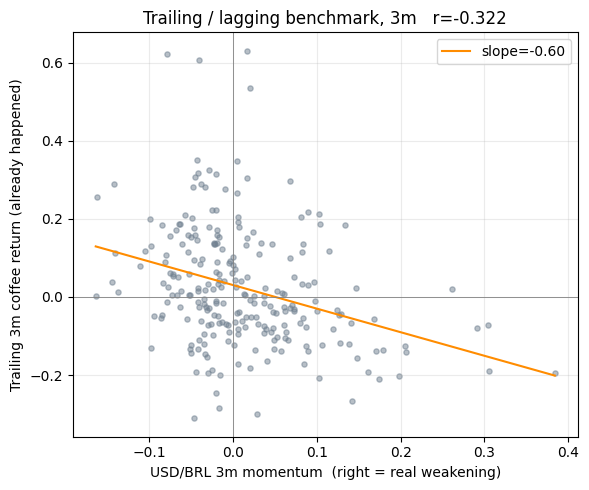

In [7]:
# Trailing (lagging) r at every horizon: signal_t vs coffee's PAST N-month return.
trail_rows = []
for N in HORIZONS:
    c = monthly.dropna(subset=["brl_roc_3m", f"trl_{N}m"])
    r, p = stats.pearsonr(c["brl_roc_3m"], c[f"trl_{N}m"])
    trail_rows.append({"horizon_m": N, "r_trailing": r, "p_value": p, "n": len(c)})
trail = pd.DataFrame(trail_rows).set_index("horizon_m")
print("Trailing r( brl_roc_3m_t , PAST coffee return t-N -> t ):\n")
print(trail.to_string())

# Representative scatter at 3m (signal vs the coffee move that already happened).
cc = monthly.dropna(subset=["brl_roc_3m", "trl_3m"])
r_trail_3m = trail.loc[3, "r_trailing"]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(cc["brl_roc_3m"], cc["trl_3m"], s=14, alpha=0.5, color="slategray")
b1, b0 = np.polyfit(cc["brl_roc_3m"], cc["trl_3m"], 1)
xs = np.linspace(cc["brl_roc_3m"].min(), cc["brl_roc_3m"].max(), 50)
ax.plot(xs, b0 + b1 * xs, color="darkorange", lw=1.5, label=f"slope={b1:+.2f}")
ax.axhline(0, color="gray", lw=0.6)
ax.axvline(0, color="gray", lw=0.6)
ax.set_xlabel("USD/BRL 3m momentum  (right = real weakening)")
ax.set_ylabel("Trailing 3m coffee return (already happened)")
ax.set_title(f"Trailing / lagging benchmark, 3m   r={r_trail_3m:+.3f}")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Forward-Predictive Test — the core question

**Question:** does USD/BRL momentum known **at time t** predict the coffee return over the **following N months**?

For each horizon N we compute

```
r( brl_roc_3m_t ,  fwd_{N}m_t )      where  fwd_{N}m_t = Coffee_{t+N}/Coffee_t - 1
```

The signal is fixed at t (past prices only); the return is realised entirely after t. **The thesis predicts a negative r** (real weakening at t → cheaper coffee by t+N). We report r, the two-sided p-value, and n at every horizon, and read off **where** (if anywhere) the predictive edge lives. A fast supply channel should peak at short horizons (1–6m) and decay by 12–24m — the opposite horizon profile to NB1's slow mean-reversion signal.

> **Gate 1** passes if forward r is negative with p < 0.10 at some N. **Gate 2** passes if, at that horizon, the **forward** |r| is at least as large as the **trailing** |r| from §4 (same horizon) — i.e. the signal genuinely *leads* coffee rather than lagging or coinciding with it.

In [8]:
# Forward-predictive correlation across all horizons.
# For each N: align the signal (known at t) with the strictly-forward return,
# drop rows where either is NaN, then Pearson r + p-value.
rows = []
for N in HORIZONS:
    c = monthly.dropna(subset=["brl_roc_3m", f"fwd_{N}m"])
    r, p = stats.pearsonr(c["brl_roc_3m"], c[f"fwd_{N}m"])
    rows.append({"horizon_m": N, "r": r, "p_value": p, "n": len(c)})

fwd = pd.DataFrame(rows).set_index("horizon_m")
fwd["sig_10pct"] = fwd["p_value"] < 0.10          # passes Gate-1 threshold?
fwd["matches_thesis"] = fwd["r"] < 0              # negative = thesis direction
print("Forward-predictive r( brl_roc_3m_t , coffee return t -> t+N ):\n")
print(fwd.to_string())

best = fwd["r"].abs().idxmax()
fwd_r_best  = fwd.loc[best, "r"]
trl_r_best  = trail.loc[best, "r_trailing"]   # horizon-matched benchmark from §4
print(f"\nStrongest |r| at horizon = {best} months : "
      f"r={fwd_r_best:+.3f}, p={fwd.loc[best,'p_value']:.2e}")
print(f"Horizon-matched TRAILING r at {best}m (from §4): r={trl_r_best:+.3f}")
print("Gate 2 (forward |r| >= trailing |r| at same horizon => signal LEADS): "
      f"{'PASS' if abs(fwd_r_best) >= abs(trl_r_best) else 'FAIL'}")

Forward-predictive r( brl_roc_3m_t , coffee return t -> t+N ):

                r  p_value    n  sig_10pct  matches_thesis
horizon_m                                                 
1          0.0100   0.8781  240      False           False
2         -0.0120   0.8537  239      False            True
3         -0.0340   0.6021  238      False            True
6         -0.0431   0.5110  235      False            True
12         0.0237   0.7214  229      False           False
24         0.0843   0.2162  217      False           False

Strongest |r| at horizon = 24 months : r=+0.084, p=2.16e-01
Horizon-matched TRAILING r at 24m (from §4): r=-0.185
Gate 2 (forward |r| >= trailing |r| at same horizon => signal LEADS): FAIL


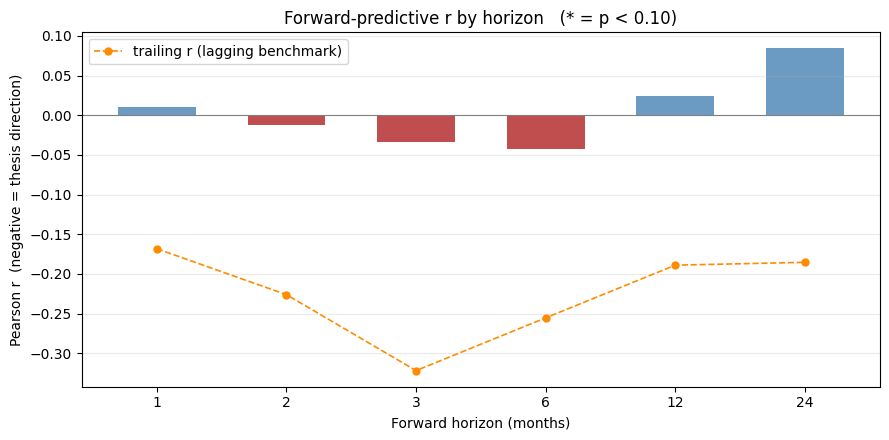

In [ ]:
# Bar chart of forward r by horizon. Bars below zero match the thesis direction.
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["firebrick" if r < 0 else "steelblue" for r in fwd["r"]]
bars = ax.bar(fwd.index.astype(str), fwd["r"], color=colors, alpha=0.8, width=0.6)

# Mark statistical significance (p<0.10) with a star above/below the bar.
for x, (N, row) in zip(bars, fwd.iterrows()):
    if row["p_value"] < 0.10:
        yoff = -0.02 if row["r"] < 0 else 0.02
        ax.text(x.get_x() + x.get_width()/2, row["r"] + yoff, "*",
                ha="center", va="center", fontsize=16, fontweight="bold")

ax.axhline(0, color="gray", lw=0.8)
ax.plot(fwd.index.astype(str), trail["r_trailing"].reindex(fwd.index).values,
        "o--", color="darkorange", lw=1.2, ms=5, label="trailing r (lagging benchmark)")
ax.set_xlabel("Forward horizon (months)")
ax.set_ylabel("Pearson r  (negative = thesis direction)")
ax.set_title("Forward-predictive r by horizon   (* = p < 0.10)")
ax.legend()
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

## 5b. Stability Across Time — is it one episode?

A single full-sample r can be entirely manufactured by one dramatic regime. The 2014–2016 real collapse and the 2020 COVID shock are the obvious suspects: both featured a violently weakening real *and* falling coffee, which would print a strong negative r even if no stable mechanism exists the rest of the time.

Two checks at the best horizon from §5:
1. **Rolling 36-month correlation** — does the predicted (negative) sign persist, or does it appear only in bursts?
2. **Subperiod breakdown** — split the sample (pre-2012 / 2012–2016 / 2017–2019 / 2020–2021 / 2022+) and recompute r in each. If the effect lives in *one* block and flips elsewhere, Gate 3 fails and the signal is an artifact of a regime, not a usable rule.

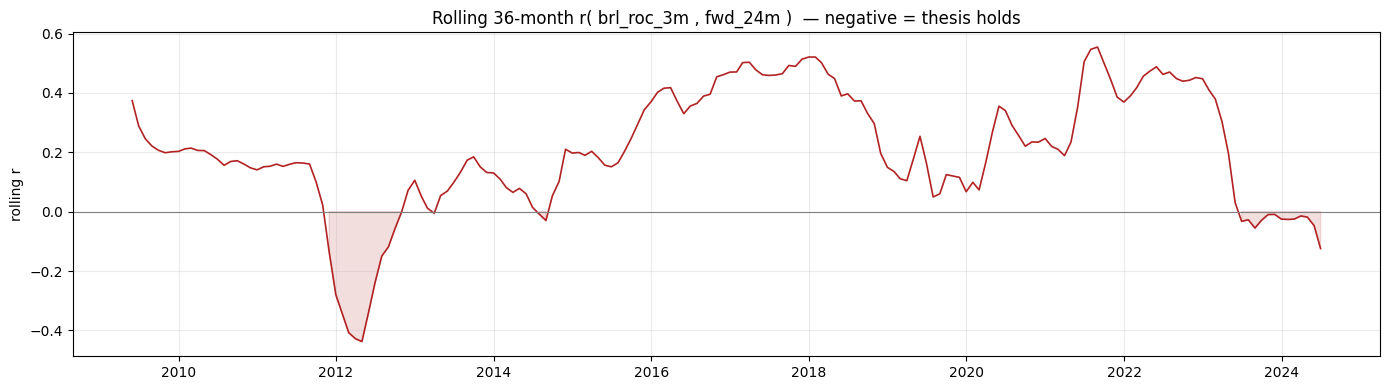

Rolling-36m r : mean=+0.207  min=-0.438  max=+0.555
Fraction of rolling windows with thesis sign (r<0): 15%

Subperiod forward r at N=24m:

               r  p_value   n
period                       
pre-2012  0.0689   0.5796  67
2012-2016 0.3008   0.0195  60
2017-2019 0.0672   0.6968  36
2020-2021 0.4148   0.0439  24
2022+     0.0453   0.8121  30


In [10]:
# Use the best horizon identified in §5.
BEST_N = int(best)
sig_col, tgt_col = "brl_roc_3m", f"fwd_{BEST_N}m"
pair = monthly.dropna(subset=[sig_col, tgt_col]).copy()

# --- 1. Rolling 36-month correlation ---
roll_corr = pair[sig_col].rolling(36).corr(pair[tgt_col])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll_corr.index, roll_corr, color="firebrick", lw=1.2)
ax.axhline(0, color="gray", lw=0.8)
ax.fill_between(roll_corr.index, 0, roll_corr, where=roll_corr < 0,
                color="firebrick", alpha=0.15)
ax.set_title(f"Rolling 36-month r( brl_roc_3m , fwd_{BEST_N}m )  — negative = thesis holds")
ax.set_ylabel("rolling r")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Rolling-36m r : mean={roll_corr.mean():+.3f}  "
      f"min={roll_corr.min():+.3f}  max={roll_corr.max():+.3f}")
frac_thesis = (roll_corr.dropna() < 0).mean()
print(f"Fraction of rolling windows with thesis sign (r<0): {frac_thesis:.0%}")

# --- 2. Subperiod breakdown ---
bands = {
    "pre-2012":   ("2005-01-01", "2011-12-31"),
    "2012-2016":  ("2012-01-01", "2016-12-31"),
    "2017-2019":  ("2017-01-01", "2019-12-31"),
    "2020-2021":  ("2020-01-01", "2021-12-31"),
    "2022+":      ("2022-01-01", "2099-12-31"),
}
sub_rows = []
for label, (a, b) in bands.items():
    seg = pair.loc[a:b]
    if len(seg) >= 12:                       # need enough points for a meaningful r
        r, p = stats.pearsonr(seg[sig_col], seg[tgt_col])
        sub_rows.append({"period": label, "r": r, "p_value": p, "n": len(seg)})
    else:
        sub_rows.append({"period": label, "r": np.nan, "p_value": np.nan, "n": len(seg)})

sub = pd.DataFrame(sub_rows).set_index("period")
print(f"\nSubperiod forward r at N={BEST_N}m:\n")
print(sub.to_string())

## 6. Signal-Form Comparison

Which representation of the FX *trend* predicts best at the chosen horizon: recent momentum (`brl_roc_3m`), stretch-from-trend (`brl_ma_dev`), or the raw **level** (`usdbrl`) as an adversarial control?

The raw level is the control: if the *level* predicts as well as the *trend*, then "trend" was never the operative variable and the framing should change. We compare forward r at `BEST_N` for all three. The winner here is the feature a later gated-signal notebook should carry forward.

In [11]:
# Add the raw level as a (z-scored) control feature, then compare forward r.
monthly["brl_level"] = monthly["usdbrl"]   # raw level control

forms = {"brl_roc_3m": "3m momentum (trend)",
         "brl_ma_dev": "6m MA-deviation (stretch)",
         "brl_level":  "raw USD/BRL level (control)"}

cmp_rows = []
for col, desc in forms.items():
    c = monthly.dropna(subset=[col, tgt_col])
    r, p = stats.pearsonr(c[col], c[tgt_col])
    cmp_rows.append({"feature": col, "description": desc, "r": r,
                     "p_value": p, "n": len(c)})

cmp = pd.DataFrame(cmp_rows).set_index("feature")
print(f"Forward r vs coffee return at N={BEST_N}m, by signal form:\n")
print(cmp.to_string())

winner = cmp["r"].abs().idxmax()
print(f"\nStrongest predictor at N={BEST_N}m: '{winner}'  "
      f"({forms[winner]})  r={cmp.loc[winner,'r']:+.3f}")
print("Trend beats raw level: "
      f"{'YES' if cmp.loc[winner].name != 'brl_level' else 'NO — reconsider the trend framing'}")

Forward r vs coffee return at N=24m, by signal form:

                            description      r  p_value    n
feature                                                     
brl_roc_3m          3m momentum (trend) 0.0843   0.2162  217
brl_ma_dev    6m MA-deviation (stretch) 0.1167   0.0887  214
brl_level   raw USD/BRL level (control) 0.3523   0.0000  220

Strongest predictor at N=24m: 'brl_level'  (raw USD/BRL level (control))  r=+0.352
Trend beats raw level: NO — reconsider the trend framing


## 7. Findings & Deferred Analyses

**Read the three gates against the tables above:**
- **Gate 1 (effect exists):** is forward r negative with p < 0.10 at some horizon? (§5 table)
- **Gate 2 (predictive, not just simultaneous):** is the strongest forward |r| ≥ the contemporaneous |r|? (§5 vs §4)
- **Gate 3 (not one episode):** does the rolling correlation keep the thesis sign across most windows, and does the subperiod table avoid having the entire effect in a single regime? (§5b)

**Crucial caveat — why even a clean PASS here is only suggestive.** This notebook ran the *raw* test. A negative forward r is fully consistent with the signal being **nothing but the broad dollar** (a strong USD drags down USc/lb coffee *and* weakens the real simultaneously), and the contemporaneous correlation could be **reverse causality** (coffee revenue supporting the real). Neither has been ruled out yet. The result is a green light to investigate, not a validated signal.

**Deferred analyses (scaffolded below).** The next notebook should, in order:
1. **Orthogonalise vs the broad dollar (DXY).** Regress both coffee returns and BRL momentum on DXY momentum; test whether the *residual* BRL signal still predicts the *residual* coffee return. This is the single most important control — it separates a coffee-specific producer-selling signal from generic dollar beta.
2. **Reverse-causality / lead-lag (Granger-style).** Test BRL→coffee against coffee→BRL to confirm the arrow points the way the thesis claims.
3. **Import-weighted FX basket.** Replace single-country BRL with a US-green-import-weighted basket (BRL, COP, …) using USDA FAS / Census trade shares; re-run §5 on the basket momentum.
4. **Gated buy-timing signal.** Only if 1–3 hold: convert the surviving signal into a buy/wait rule and validate it on **cost-saving %** with walk-forward testing, exactly as NB1 did.

The cell below is a non-executed scaffold (clear inputs/outputs documented) so each deferred step slots into a future notebook without rework.

In [13]:
# ─────────────────────────────────────────────────────────────────────────
# DEFERRED-ANALYSIS SCAFFOLD  (documented stubs — not run in this notebook)
# Each function states its inputs/outputs/problem so the next notebook can
# implement the body directly. DXY ticker on Yahoo: "DX-Y.NYB" (index) or
# "DX=F" (ICE dollar-index futures).
# ─────────────────────────────────────────────────────────────────────────

def orthogonalize_vs_dollar(coffee_ret, brl_mom, dxy_mom):
    """Strip the broad-dollar factor, then test the residual BRL->coffee edge.

    Problem : a raw negative r(brl_mom, coffee_ret) may be 100% dollar beta.
    Inputs  : three aligned monthly Series (coffee fwd return, BRL momentum,
              DXY momentum).
    Output  : Pearson r and p between the BRL-residual and coffee-residual
              after both are regressed on DXY momentum. A surviving negative r
              is the first real evidence of a COFFEE-SPECIFIC channel.
    Method  : resid_coffee = coffee_ret - OLS(coffee_ret ~ dxy_mom);
              resid_brl    = brl_mom    - OLS(brl_mom    ~ dxy_mom);
              return pearsonr(resid_brl, resid_coffee).
    """
    raise NotImplementedError("Implement in notebook 03 (dollar control).")


def granger_lead_lag(coffee_ret, brl_mom, max_lag=6):
    """Test direction of causation: BRL->coffee vs coffee->BRL.

    Problem : contemporaneous correlation cannot tell which series leads;
              coffee export revenue can drive the real (reverse causality).
    Inputs  : aligned monthly Series + max lag in months.
    Output  : dict of {lag: (p_brl_causes_coffee, p_coffee_causes_brl)} from a
              Granger test (e.g. statsmodels grangercausalitytests). The thesis
              needs BRL->coffee significant while coffee->BRL is weaker.
    """
    raise NotImplementedError("Implement in notebook 03 (reverse causality).")


def build_import_weighted_fx(fx_panel, import_shares):
    """Generalise BRL to a US-green-import-weighted producer-FX basket.

    Problem : Brazil is dominant but not the whole US supply; weighting by what
              the US actually imports gives a more practical signal.
    Inputs  : fx_panel (DataFrame of USD/<ccy> momentum per origin, e.g. BRL,
              COP) ; import_shares (Series of US green-coffee import weights by
              origin, from USDA FAS / Census, renormalised to sum to 1).
    Output  : a single weighted-basket momentum Series to feed back into §5.
    """
    raise NotImplementedError("Implement in notebook 04 (FX basket).")


print("Scaffold loaded. Deferred steps: dollar control -> reverse causality "
      "-> FX basket -> gated buy-signal.")

Scaffold loaded. Deferred steps: dollar control -> reverse causality -> FX basket -> gated buy-signal.
